K-means 

In [1]:
import mglearn
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [5]:
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv('single_variable_data.csv')

In [4]:
df.head()

,risk_depression,risk_drug,risk_iadl,risk_health,risk_age,risk_housing_tenure,risk_unemployed,risk_subj_econ,risk_housing_safety,risk_housing_env,...,risk_smoke,risk_alcohol,risk_suicide,risk_network,risk_infra_gap,risk_aging_rate,risk_health_is_missing,risk_subj_econ_is_missing,risk_housing_env_is_missing,risk_digital_is_missing
0,0.000000,0.1,0.0,0.25,0.514286,0.0,1.0,0.25,0.1250,0.25,...,0.0,1.0,0.0,0.333333,0.621723,0.310723,0,0,0,0
1,0.333333,0.2,0.0,0.75,0.371429,1.0,1.0,0.75,0.6250,0.75,...,0.0,0.0,0.0,0.500000,0.621723,0.310723,0,0,0,0
2,0.133333,0.1,0.0,0.75,0.057143,0.0,0.0,0.75,0.6250,0.50,...,1.0,0.0,0.0,0.333333,0.621723,0.310723,0,0,0,0
3,0.133333,0.0,0.0,0.50,0.571429,0.0,1.0,0.25,0.5000,0.25,...,0.0,0.0,0.0,0.333333,0.621723,0.310723,0,0,0,0
4,0.800000,0.5,0.0,0.75,0.571429,1.0,1.0,0.75,0.5625,0.75,...,0.0,1.0,0.0,0.000000,0.621723,0.310723,0,0,0,0


In [7]:
n_clusters = 4
kmeans = KMeans(n_clusters = n_clusters)
kmeans.fit(df)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [8]:
kmeans_labels = kmeans.labels_

In [9]:
silhouette_score(df, kmeans_labels)

0.19893813642974598

In [35]:
inertia_kmeans = []
sil_scores_kmeans = []
K_range = range(2,14)

for n_clusters in K_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    # n_init: initial centroid 변경횟수 
    # 없이 했다가 추가하니까 실루엣스코어 살짝씩 올랐음
    cluster_labels = kmeans.fit_predict(df)
    
    inertia_kmeans.append(kmeans.inertia_)
    sil_scores_kmeans.append(silhouette_score(df, cluster_labels))

In [36]:
sil_scores_kmeans

[0.18618120762379867,
 0.179343461850683,
 0.19893813642974598,
 0.20683276757906943,
 0.19133199670916584,
 0.19467630107399403,
 0.20208502730154082,
 0.17083032859286365,
 0.18262308060503582,
 0.17942448804958763,
 0.1720059084136854,
 0.17751734259166205]

In [31]:
inertia

[]

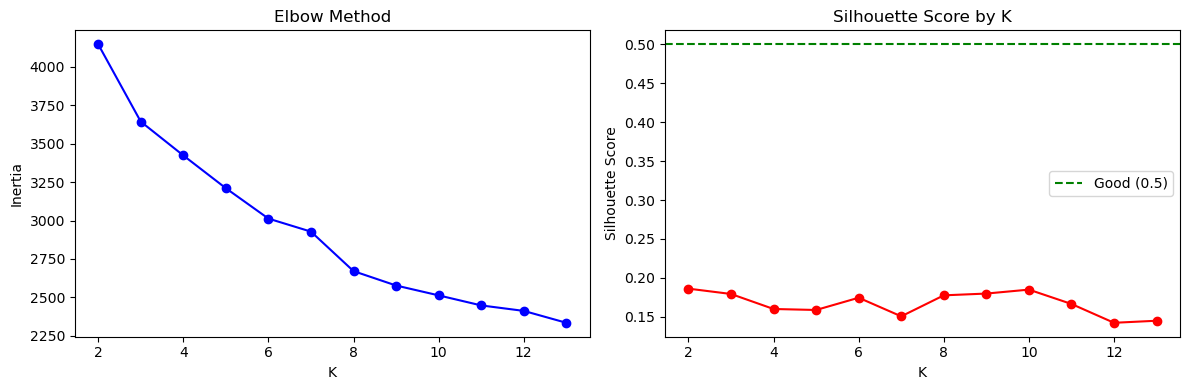

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertia_kmeans, 'bo-')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores_kmeans, 'ro-')
axes[1].axhline(y=0.5, color='g', linestyle='--', label='Good (0.5)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].legend()
plt.tight_layout()
plt.show()

In [15]:
from sklearn.cluster import AgglomerativeClustering

In [16]:
agg = AgglomerativeClustering(n_clusters=4)
agg.fit(df)

,n_clusters,4
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [17]:
agg_labels = agg.labels_

In [18]:
silhouette_score(df, agg_labels)

0.11351173954000691

In [21]:
sil_scores_agg = []

for n_clusters in range(2,12):
    agg = AgglomerativeClustering(n_clusters=n_clusters)
    agg_labels = agg.fit_predict(df)
    
    sil_scores_agg.append(silhouette_score(df, agg_labels))

In [22]:
sil_scores_agg

[0.14277164802891823,
 0.1167353658634791,
 0.11351173954000691,
 0.14491540560912677,
 0.16668452262948286,
 0.1738606694994761,
 0.15036914951935393,
 0.16279616093669413,
 0.17312769849108728,
 0.1812780434308039]

In [23]:
from sklearn.cluster import DBSCAN

In [24]:
dbscan = DBSCAN()
dbscan.fit(df)

,eps,0.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [25]:
dbscan_labels = dbscan.labels_